# 🚀 The Ultimate Kaggle Starter Template (XGBoost Edition)
**Welcome to your competition journey!** This notebook is designed to take you from raw data to a submittable model using the industry-standard XGBoost algorithm.

> **Tip for Beginners:** Cells marked with `[EDIT REQUIRED]` are places where you'll need to change code to match your specific dataset. Everything else should work out of the box!

---

### 📑 Table of Contents
0. [Kaggle Auth & Download (Colab Only)](#auth)
1. [Environment & Library Imports](#setup)
2. [Data Loading & Inspection](#loading)
3. [Deep Exploratory Data Analysis (EDA)](#eda)
4. [Advanced Graphical Presentation](#viz)
5. [Preprocessing & Feature Engineering](#prep)
6. [Model Training with XGBoost](#modeling)
7. [Performance Evaluation](#eval)
8. [Submission Production](#submit)

<a id='auth'></a>
## 🔑 Step 0: Kaggle Authentication (Colab Only)

If you are running this on **Google Colab**, you need to give it access to your Kaggle account to download the data. 

**Instructions:**
1. Go to your Kaggle account settings and click **"Create New API Token"**. This downloads a `kaggle.json` file.
2. Run the cells below to upload that file.

In [3]:
# --- OPTION 1: Upload kaggle.json manually ---
try:
    from google.colab import files
    print("Please upload your kaggle.json file:")
    files.upload()
except ImportError:
    print("Not running in Colab. Skipping manual upload.")

Please upload your kaggle.json file:


In [1]:
# --- OPTION 2: Use kaggle.json from Google Drive ---
# (Uncomment the lines below if you prefer to load from Drive)

from google.colab import drive
drive.mount('/content/drive')
!cp drive/MyDrive/kaggle.json .
!cp drive/MyDrive/kaggle.zip .
!if [ -f kaggle.json ]; then exit 1; fi; unzip kaggle.zip

Mounted at /content/drive


In [2]:
# --- Setting up the Kaggle Directory ---
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle credentials configured!")

✅ Kaggle credentials configured!


In [3]:

# --- [EDIT REQUIRED] Download Dataset ---
COMPETITION_NAME = 'house-prices-advanced-regression-techniques' # [CHANGE REQUIRED] Change 'titanic' to your competition name!

!kaggle competitions download -c {COMPETITION_NAME}
!unzip -o {COMPETITION_NAME}.zip # -o overwrites existing files

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 503MB/s]
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


<a id='setup'></a>
## 🛠 1. Environment & Library Imports

To build a model, we need several tools:
*   `pandas` & `numpy` for handling data tables.
*   `matplotlib` & `seaborn` for drawing graphs.
*   `xgboost` for the powerful Extreme Gradient Boosting model.

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import ydf

# Machine Learning libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Settings to make it look pretty
%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_palette("viridis")
warnings.filterwarnings('ignore') # Hides annoying warnings
pd.set_option('display.max_columns', None) # Show all columns in tables

print("🚀 Global settings initialized. Ready for analysis.")

🚀 Global settings initialized. Ready for analysis.


<a id='loading'></a>
## 📁 2. Data Loading & Inspection

In Kaggle, you usually get two files:
1.  **Train (`train.csv`)**: Data used to teach the model (includes the answers).
2.  **Test (`test.csv`)**: Data where you need to predict the answers.

In [5]:
# Try to load the data
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print(f"✅ Success! Found {len(train_df)} training rows and {len(test_df)} testing rows.")
except FileNotFoundError:
    print("❌ Files not found! Did you run Step 0 or upload the CSVs?")
    train_df = test_df = None

if train_df is not None:
    display(train_df.head()) # Show the first 5 row
    print(train_df.columns)

✅ Success! Found 1460 training rows and 1459 testing rows.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

<a id='eda'></a>
## 📊 3. Exploratory Data Analysis (EDA)

Before building a model, we must "meet" the data. We check for **Missing Values** (NaNs) and see what the numbers look like.

In [6]:
if train_df is not None:
    print("--- Data Types & Non-Null Counts ---")
    print(train_df.info())
    
    print("\n--- Statistical Overview ---")
    display(train_df.describe().T)
    
    print("\n--- Missing Values Count ---")
    nulls = train_df.isnull().sum()
    print(nulls[nulls > 0])

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



--- Missing Values Count ---
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


<a id='viz'></a>
## 🎨 4. Advanced Graphical Presentation

**What are we looking at?**
We've optimized these plots to be **MAXIMUM SIZE** for readability, even with 30+ features.

### 📈 4.1 Target Distribution
Checking how our "answers" are spread out. Continuous targets are split into 36 parts.

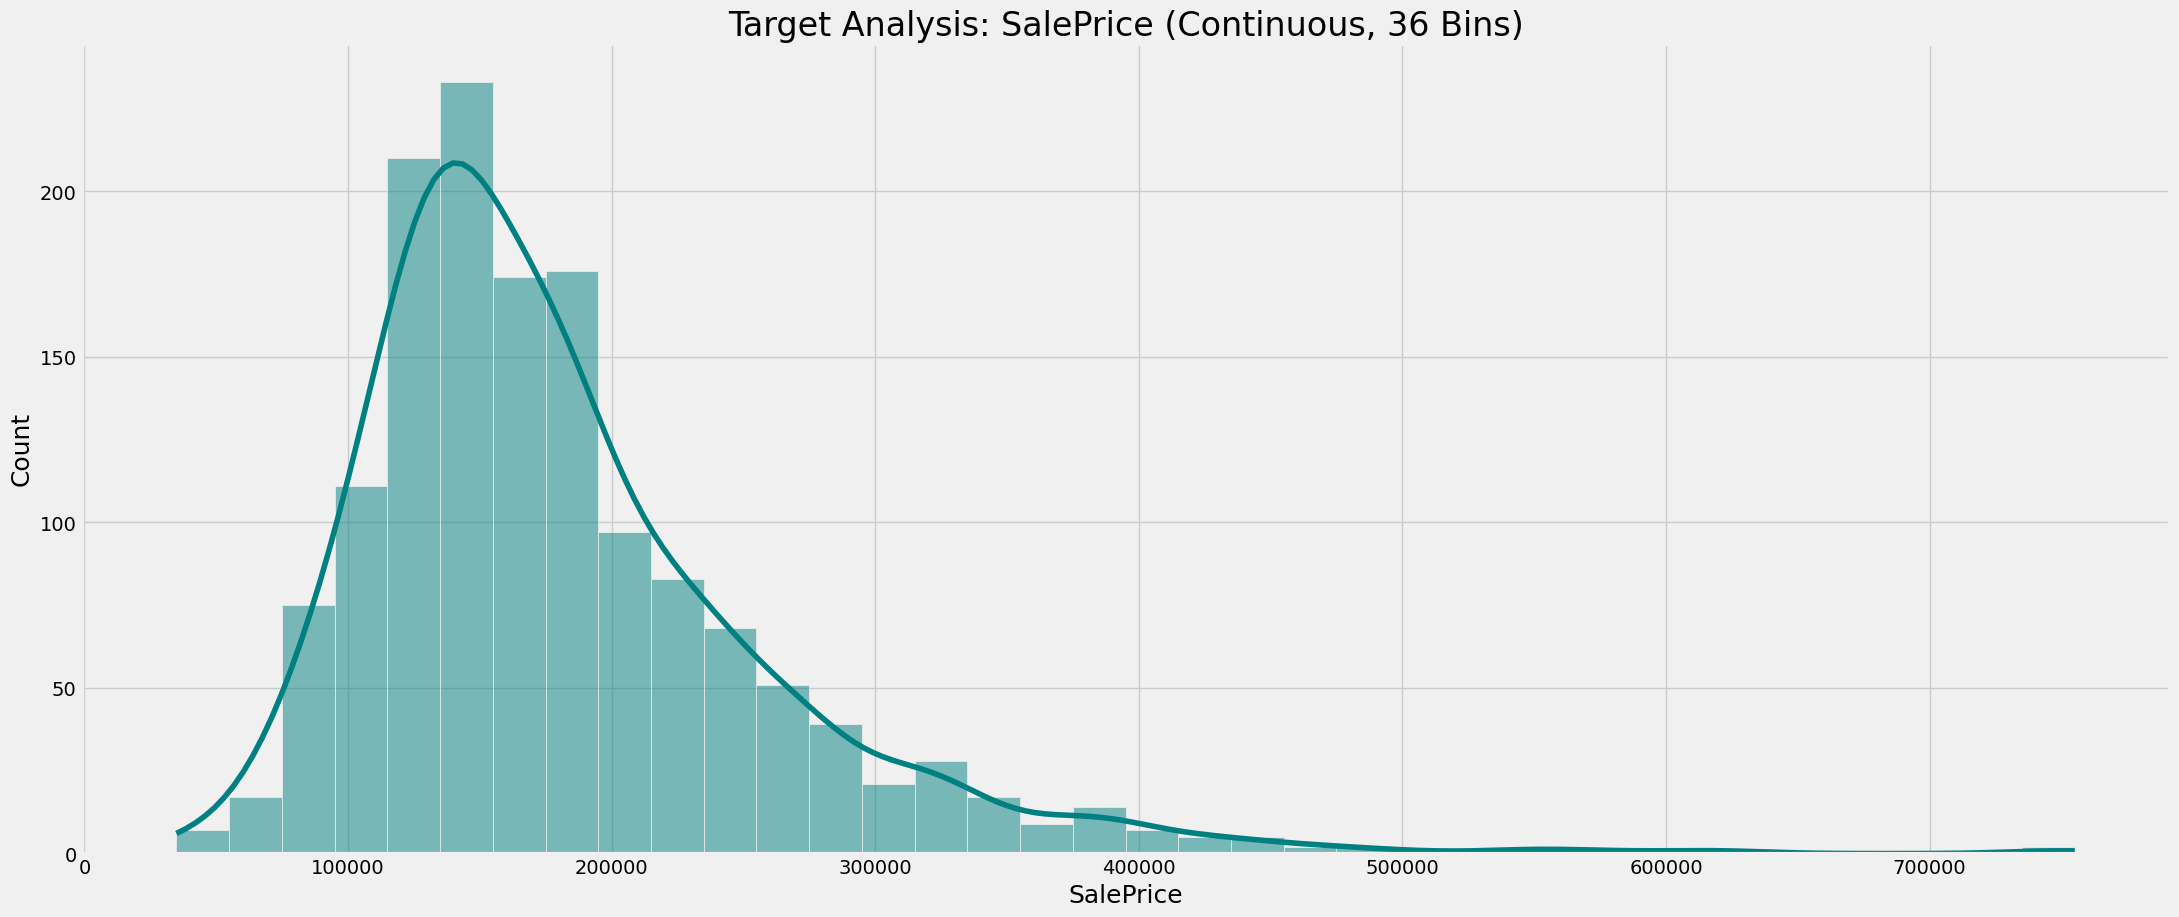

In [8]:
if train_df is not None:
    # [EDIT REQUIRED] Update target_name to your Target column!
    target_name = 'SalePrice'
    
    unique_vals = train_df[target_name].nunique()
    # 🤖 Auto-detect task type: Regression if numeric & many unique values, else classification
    is_classification = not (pd.api.types.is_numeric_dtype(train_df[target_name]) and unique_vals > 35)
    
    plt.figure(figsize=(24, 10)) # Ultra-wide for distribution
    
    if not is_classification:
        sns.histplot(train_df[target_name], bins=36, kde=True, color='teal')
        plt.title(f'Target Analysis: {target_name} (Continuous, 36 Bins)', fontsize=24)
    else:
        sns.countplot(data=train_df, x=target_name, palette='viridis')
        plt.title(f'Target Analysis: {target_name} (Categorical)', fontsize=24)
        
    plt.xlabel(target_name, fontsize=18)
    plt.ylabel('Count', fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

### 🗺️ 4.2 Feature Correlation Matrix
This massive square map shows how every feature talks to every other feature. Great for spotting redundant data!

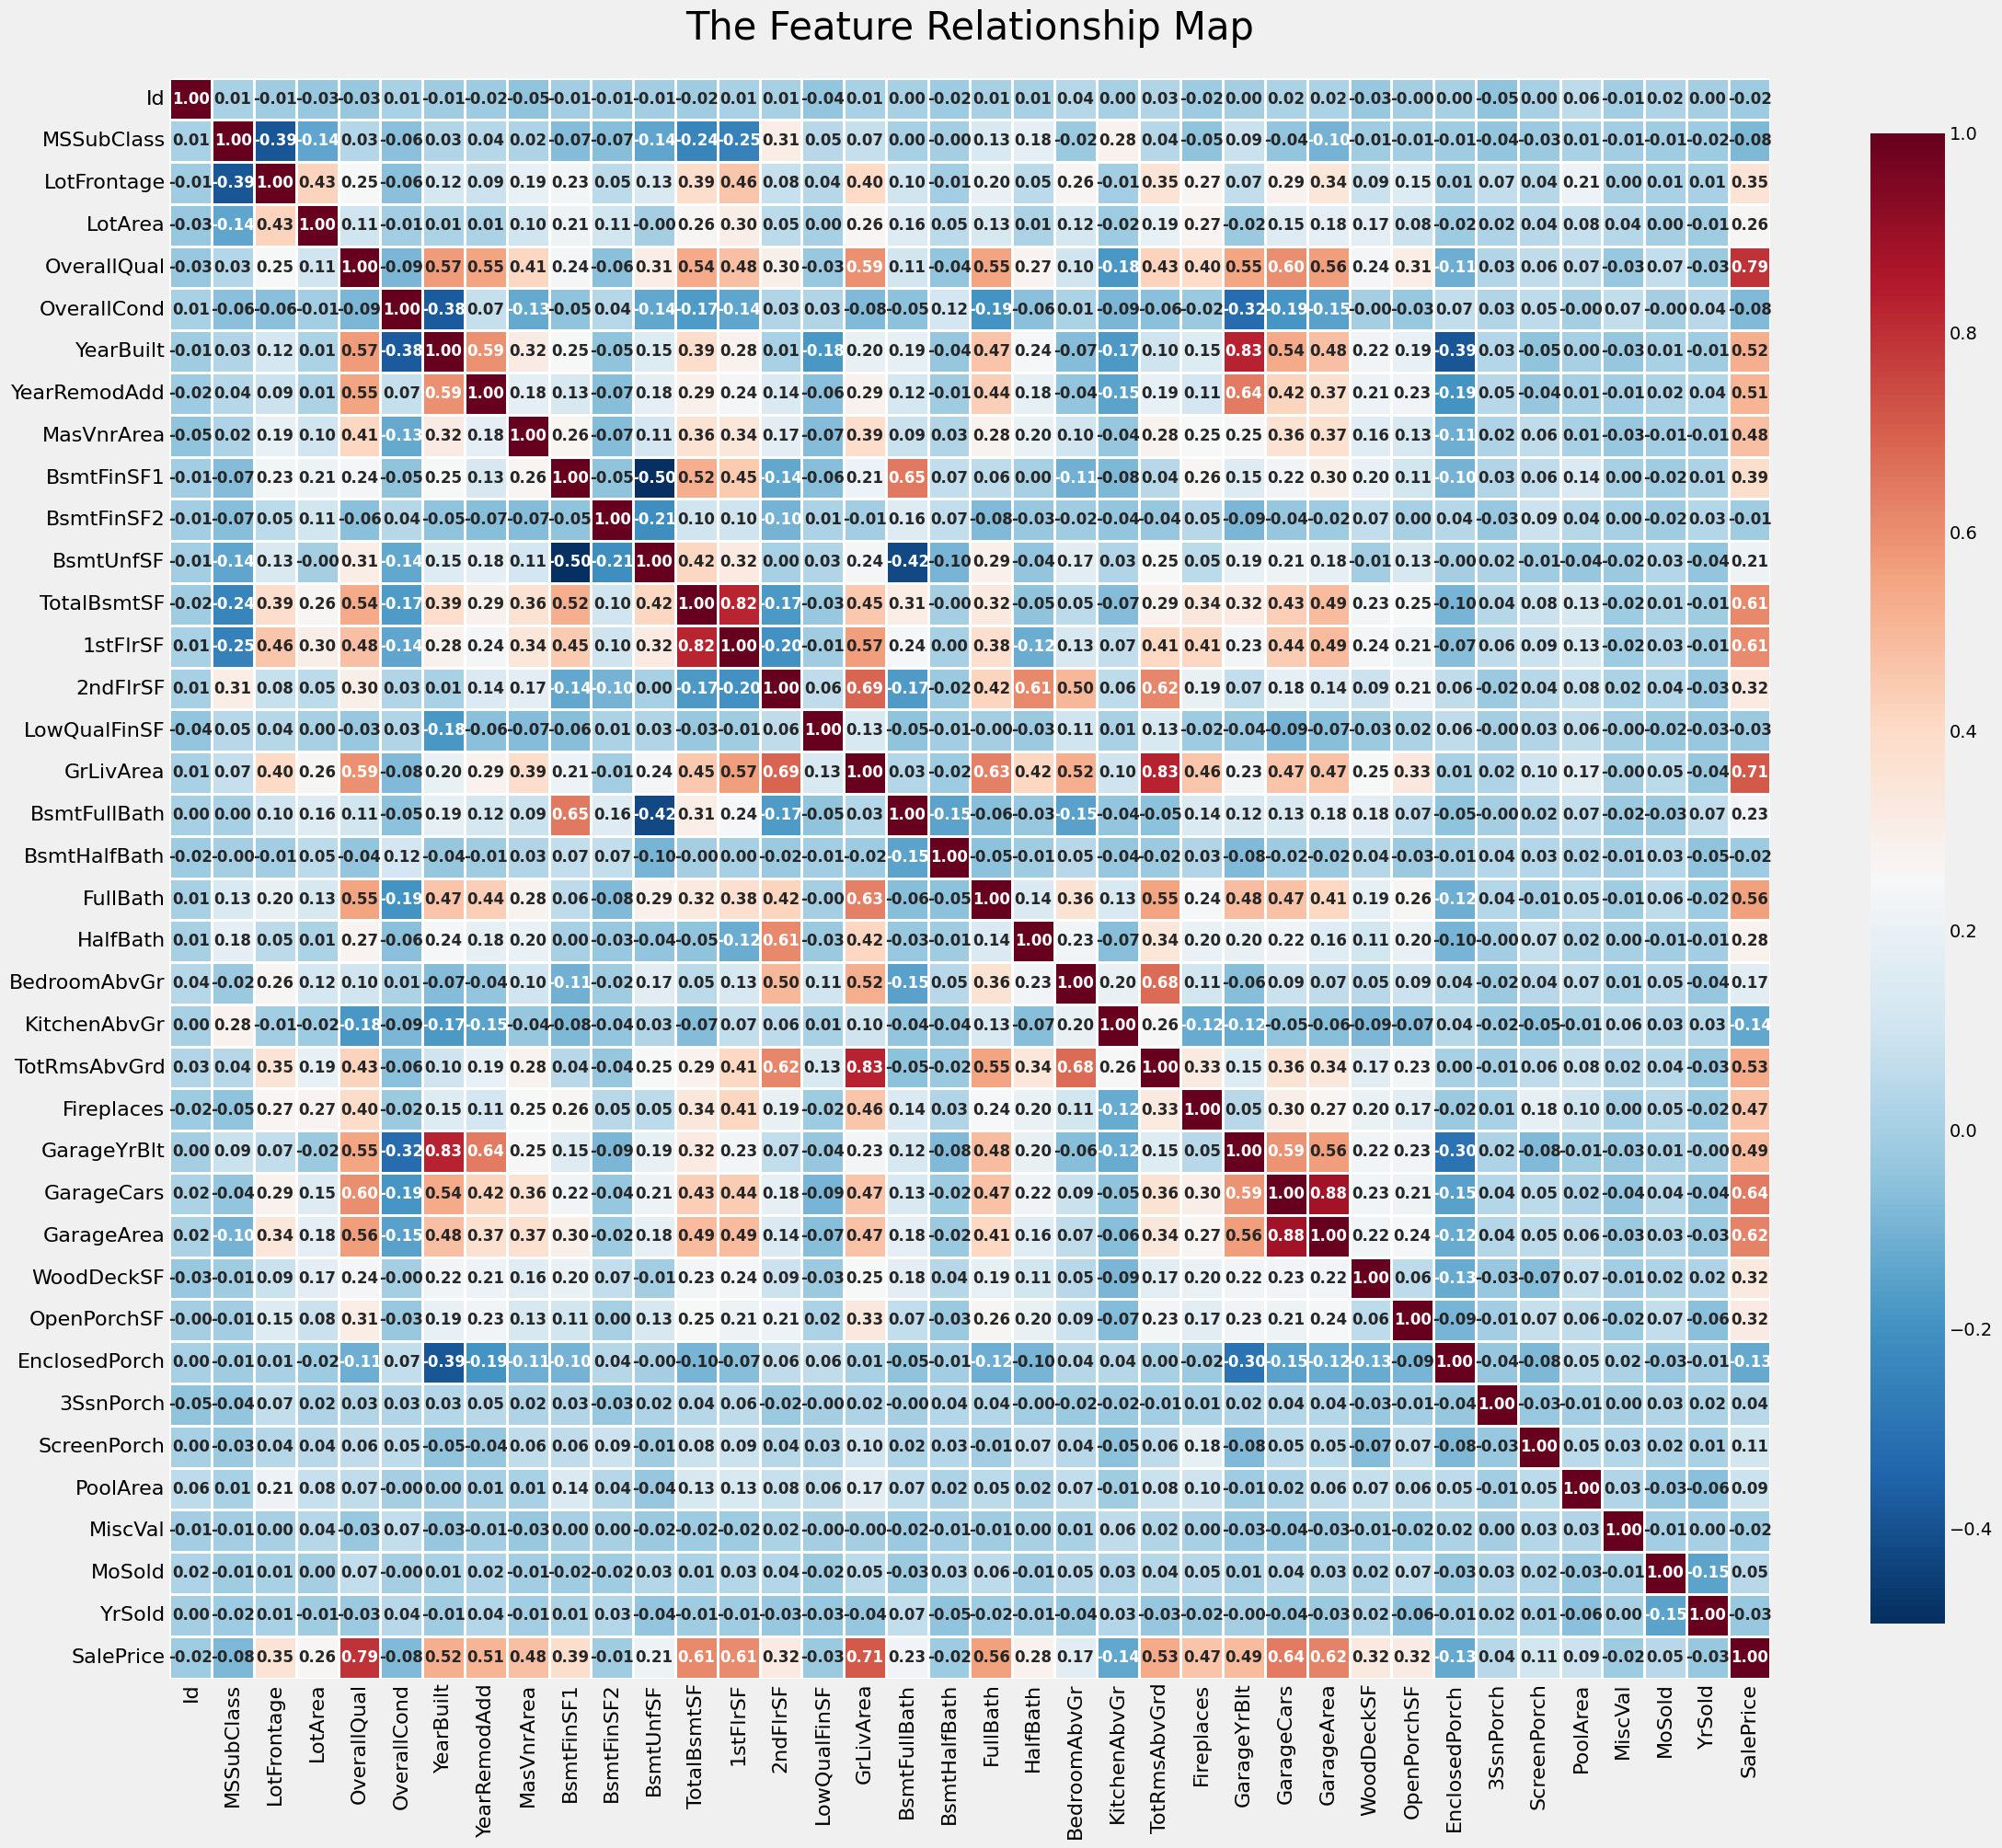

In [9]:
if train_df is not None:
    numeric_cols = train_df.select_dtypes(include=[np.number])
    
    # Huge Square Figure for clarity
    plt.figure(figsize=(25, 25))
    
    # Calculate correlation
    corr = numeric_cols.corr()
    
    # Plotting
    sns.heatmap(corr, 
                annot=True, 
                cmap='RdBu_r', 
                fmt='.2f', 
                square=True, 
                linewidths=1.0, 
                cbar_kws={"shrink": .8},
                annot_kws={"size": 12, "weight": "bold"}) # Bigger, bolder fonts
    
    plt.title('The Feature Relationship Map', fontsize=30, pad=30)
    plt.xticks(fontsize=16, rotation=90)
    plt.yticks(fontsize=16)
    
    plt.show()

<a id='prep'></a>
## 🛠 5. Preprocessing & Feature Engineering

Machine Learning models don't like text (like "Male"/"Female") or missing values. 
We use a combination of **Custom Logic** and a **Pipeline** to automatically handle data:

### Part 1: Smart Automated Feature Engineering
1.  **Missing Value Indicators**: If any column has missing values, we create a `{col}_isMissing` feature (1 if missing, 0 if present) to help the model learn from the *fact* that data was missing.
2.  **Low Correlation Pruning**: For numeric columns, if the correlation with the target is extremely weak (absolute value < 0.05), we drop them. Less noise helps the model focus on true signals!
3.  **High Cardinality Dropping**: If a categorical (text) column has too many unique values (e.g., > 50% of the dataset size), it's likely an ID or a name and will overcomplicate the model. We drop it. Otherwise, we keep it to process normally.

### Part 2: The Sklearn Pipeline
1.  Fill in remaining missing numbers with the **Median**.
2.  Turn text categories into **Numbers** (One-Hot Encoding).
3.  Scale numbers so they are all in the same range.


In [23]:
def clean_and_feature(df, is_train=False):
    """Local function for custom automated data cleaning and feature engineering."""
    df = df.copy()
    
    # 1. Missing value indicators
    # Creates a helper column for every column that has empty values
    for col in df.columns:
        if df[col].isnull().any():
            df[f"{col}_isMissing"] = df[col].isnull().astype(int)
    
    # 2. Drop standard ID and high-text columns
    drops = [c for c in ['PassengerId', 'Name', 'Id', 'id', 'Ticket'] if c in df.columns]
    if len(drops) > 0:
        print(f"🔹 Dropping basic ID/text columns: {drops}")
        df = df.drop(columns=drops)

    # 3. Handle mixed types in categorical columns (e.g., bool + strings)
    # This prevents TypeError in scikit-learn's OneHotEncoder during fitting
    cat_check_cols = df.select_dtypes(include=['object', 'bool']).columns
    for col in cat_check_cols:
        if col != target_name:
            # Convert values to strings while preserving actual NaNs so Imputer can find them
            df[col] = df[col].map(lambda x: str(x) if pd.notnull(x) else x)

    # 4. Drop low correlation numeric columns (Train set only logic)
    global train_df
    if target_name in df.columns:
        # We are processing the training set
        corr_drops = []
        for col in df.select_dtypes(include=['number']).columns:
            if col != target_name:
                corr = df[col].corr(df[target_name])
                if abs(corr) < 0.02: # Set threshold to 0.02
                    corr_drops.append(col)
        
        if len(corr_drops) > 0:
            print(f"📉 Dropping low correlation (< 0.02) numeric columns: {corr_drops}")
            df = df.drop(columns=corr_drops)
            # Save for the test set, so we perform the EXACT same drops later
            global _saved_corr_drops
            _saved_corr_drops = corr_drops
    else:
        # We are processing the test set
        try:
            if len(_saved_corr_drops) > 0:
                drops_here = [c for c in _saved_corr_drops if c in df.columns]
                df = df.drop(columns=drops_here)
        except NameError:
            pass
            
    # 5. Drop high-cardinality metadata (names, specific cabin numbers, etc.)
    obj_drops = []
    total_rows = len(df)
    for col in df.select_dtypes(include=['object']).columns:
        if col == target_name: continue
        num_unique = df[col].nunique()
        if num_unique > 0.6 * total_rows:
            obj_drops.append(col)
            
    if len(obj_drops) > 0:
        print(f"🗑️ Dropping high-cardinality object columns (> 60% unique): {obj_drops}")
        df = df.drop(columns=obj_drops)
        
    return df

if train_df is not None:
    # Process the data
    train_clean = clean_and_feature(train_df)
    
    # IMPROVED: Define features by type, strictly EXCLUDING the target column
    # This prevents the model from accidentally "seeing" the answer
    num_features = train_clean.select_dtypes(include=['number']).columns
    cat_features = train_clean.select_dtypes(include=['object']).columns

    # --- Automatic Processing Engine ---
    # Numeric: Fill gaps with Medium, then scale result
    num_proc = Pipeline([('imputer', SimpleImputer(strategy='median')), 
                         ('scaler', StandardScaler())])
                         
    # Categorical: Fill missing with 'NA', then convert to binary numbers
    cat_proc = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

    # Assemble the final transformation blueprint
    transformer = ColumnTransformer(transformers=[
        ('num', num_proc, num_features),
        ('cat', cat_proc, cat_features)
    ])
    
    print("✅ Preprocessing engine is ready and robust!")


🔹 Dropping basic ID/text columns: ['Id']
📉 Dropping low correlation (< 0.02) numeric columns: ['BsmtFinSF2', 'BsmtHalfBath', 'LotFrontage_isMissing', 'Electrical_isMissing']
✅ Preprocessing engine is ready and robust!


# We are trying ydf

In [30]:
if train_df is not None:
    # Separate the data - YDF works best when passed the DataFrame directly
    # Split data to test the model before submitting
    X_train, X_val, y_train, y_val = train_test_split(train_clean, train_clean[target_name], test_size=0.2, random_state=42)

    # --- YDF GradientBoostedTreesLearner ---
    # YDF handles categorical features and missing values natively.
    print(f"🚀 Training YDF GradientBoostedTreesLearner on {target_name}...")
    model = ydf.GradientBoostedTreesLearner(label=target_name, 
                                            task=ydf.Task.REGRESSION,
                                            num_trees=500,
                                            max_depth=6).train(X_train)
    
    print(f"✅ YDF Training finished!")
    # Optional: See model details
    # model.describe()


🚀 Training YDF GradientBoostedTreesLearner on SalePrice...
Feature Street is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature Utilities is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature Condition2 is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Feature PoolQC is a CATEGORICAL feature with an empty dictionary. The feature will not be useful during model training.
Feature MiscFeature is a CATEGORICAL feature whose dictionary has a single element. The feature will not be useful during model training.
Train model on 1168 examples
Model trained in 0:00:11.173138
✅ YDF Training finished!


In [17]:
model.predict(test_df)

array([[2.1852615e-04, 2.1853704e-04, 2.1852205e-04, ..., 2.1852662e-04,
        2.1852333e-04, 2.1853101e-04],
       [1.3760169e-04, 1.3759162e-04, 1.3759671e-04, ..., 1.3759578e-04,
        1.3759371e-04, 1.3760563e-04],
       [9.2580696e-05, 9.2579678e-05, 9.2579692e-05, ..., 9.2584414e-05,
        9.2578106e-05, 9.2584851e-05],
       ...,
       [1.8169091e-04, 1.8165966e-04, 1.8882685e-04, ..., 1.8167596e-04,
        1.8166492e-04, 1.9649033e-04],
       [2.6860114e-04, 2.6858028e-04, 2.6859061e-04, ..., 2.6858336e-04,
        2.6857364e-04, 2.6858234e-04],
       [2.0203926e-04, 2.0203888e-04, 2.0203843e-04, ..., 2.0204042e-04,
        2.0203310e-04, 2.0203707e-04]], dtype=float32)

<a id='eval'></a>
## 🔍 7. Performance Evaluation

How well did we do? We check the accuracy score and the **Confusion Matrix** to see where the model got confused.

Now work For both Classifier and Regressor: 

🏠 RMSE (Avg Error): $25,515.19
📉 MAE: $15,749.97
📈 R2 Score: 0.9151


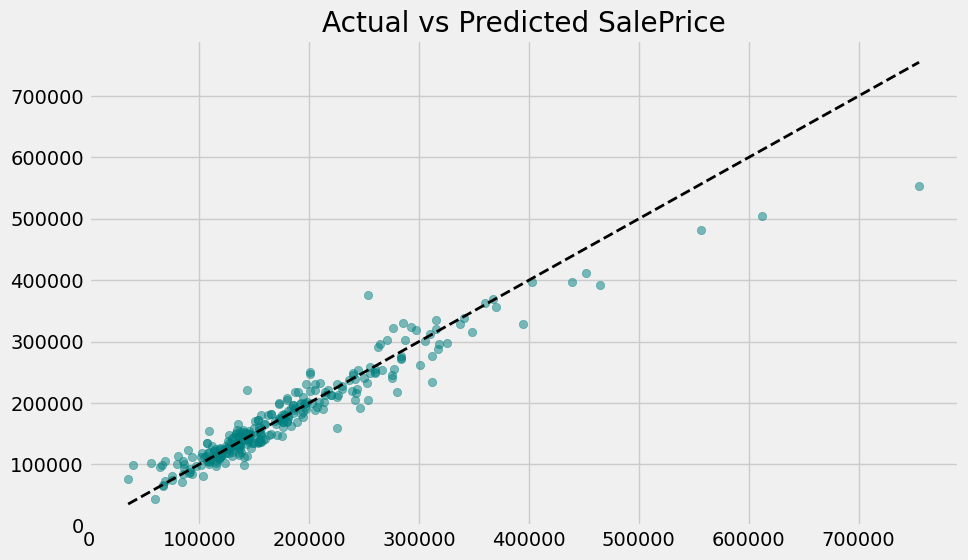

In [31]:
if train_df is not None:
    # Use the YDF model to predict on the validation set
    raw_pred = model.predict(X_val)
    
    # 🛠️ SHAPE FIX: Ensure both y_val and y_pred are simple 1D arrays
    y_pred = raw_pred.flatten() 
    y_true = y_val.values if hasattr(y_val, 'values') else y_val
    
    if is_classification:
        acc = accuracy_score(y_true, y_pred)
        print(f"🎯 Validation Accuracy: {acc:.2%}")
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Greens')
        plt.title('Confusion Matrix')
        plt.show()
    else:
        # Calculate Regression Metrics
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        print(f"🏠 RMSE (Avg Error): ${rmse:,.2f}")
        print(f"📉 MAE: ${mae:,.2f}")
        print(f"📈 R2 Score: {r2:.4f}")

        # Visualization
        plt.figure(figsize=(10, 6))
        plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
        plt.title(f'Actual vs Predicted {target_name}')
        plt.show()




<a id='submit'></a>
## 📤 8. Submission Production

Final Step! Apply the same logic to the `test.csv` file and save it to a file that Kaggle accepts.

In [32]:
if test_df is not None:
    # Clean the test data using the same logic as train data
    test_clean = clean_and_feature(test_df)
    
    # Predict using the test features
    # Note: Pass the clean test set directly
    predictions = model.predict(test_clean)
    
    # Ensure predictions are flat (avoids "Per-column arrays must each be 1-dimensional" error)
    final_predictions = predictions.flatten() if hasattr(predictions, 'flatten') else predictions

    # Create the submission file
    submission_file = pd.DataFrame({
        "Id": test_df.iloc[:, 0], 
        target_name: final_predictions
    })

    submission_file.to_csv('submission.csv', index=False)
    print("🎉 DONE! 'submission.csv' is ready for upload.")


🔹 Dropping basic ID/text columns: ['Id']
🎉 DONE! 'submission.csv' is ready for upload.


In [33]:
# Submit the generated CSV file to the Kaggle competition
!kaggle competitions submit -c house-prices-advanced-regression-techniques -f submission.csv -m "XGBoost model with engineered Title, Deck, and FamilySize features"
####################EDIT#HERE##^^^^^^^^^^^^^^^^^##EDIT#HERE######

100% 21.2k/21.2k [00:00<00:00, 38.9kB/s]
Successfully submitted to House Prices - Advanced Regression Techniques